# 수학적 정의

In [2]:
import numpy as np
f=[1,2,3]
g=[2,4]
np.convolve(f,g)

array([ 2,  8, 14, 12])

In [ ]:
np.convolve(g,f)

array([ 2,  8, 14, 12])

In [ ]:
np.convolve(f,g,mode='same')

array([ 2,  8, 14])

In [ ]:
np.convolve(f,g,mode='valid')

array([ 8, 14])

In [ ]:
np.convolve(f,g,mode='full')

array([ 2,  8, 14, 12])

In [ ]:
from sympy import symbols, integrate,exp,Heaviside,oo

x,t=symbols('x t')
integrate(exp(x)*Heaviside(t-x),(x,-oo,oo))

Integral(exp(x)*Heaviside(t - x), (x, -oo, oo))

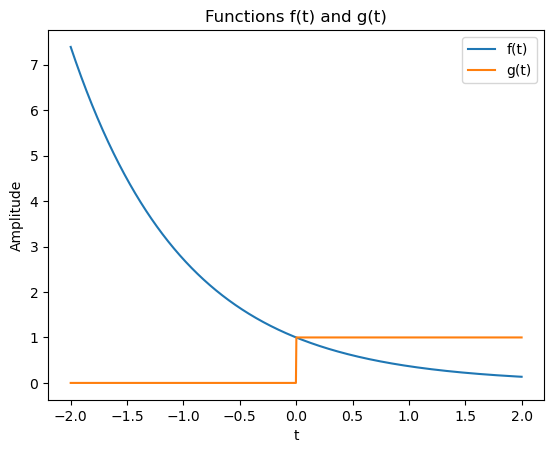

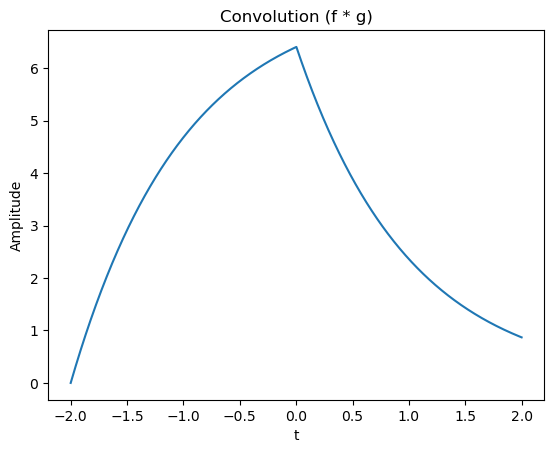

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 함수 정의
def f(t):
    return np.exp(-t)

def g(t): # heaviside 함수
    return (t >= 0).astype(float)

# 시간 범위 설정
t = np.linspace(-2, 2, 1000)

# 함수 시각화
plt.plot(t, f(t), label='f(t)')
plt.plot(t, g(t), label='g(t)')
plt.legend()
plt.title('Functions f(t) and g(t)')
plt.xlabel('t')
plt.ylabel('Amplitude')
plt.show()

# 컨볼루션 계산
dt=(t[1] - t[0]) # 샘플링 간격, 아래 결과에 곱하여 정규화 시킴
convolution_result = np.convolve(f(t), g(t), mode='same') * dt

# 컨볼루션 결과 시각화
plt.plot(t, convolution_result)
plt.title('Convolution (f * g)')
plt.xlabel('t')
plt.ylabel('Amplitude')
plt.show()

In [ ]:
import tensorflow as tf

# 1D 입력 데이터 (크기: 3, 채널: 1)
input_data = np.array(f).reshape(1,3,1)

# 1D 커널 (크기: 2, 채널: 1, 출력 채널: 1)
kernel_data = np.array(g).reshape(2, 1, 1)

# 1D 컨볼루션 연산 수행
tf.nn.convolution(input_data, kernel_data, padding='VALID')

<tf.Tensor: shape=(1, 2, 1), dtype=int32, numpy=
array([[[10],
        [16]]])>

In [ ]:
import tensorflow as tf

# 1D 입력 데이터 (크기: 3, 채널: 1)
input_data = np.array(f).reshape(1,3,1)

# 1D 커널 (크기: 2, 채널: 1, 출력 채널: 1)
kernel_data = np.array(g).reshape(2, 1, 1)

# 1D 컨볼루션 연산 수행
tf.nn.conv1d(input_data, kernel_data, stride=1, padding='VALID')

<tf.Tensor: shape=(1, 2, 1), dtype=int32, numpy=
array([[[10],
        [16]]])>

In [ ]:
import tensorflow as tf

# 1D 컨볼루션 연산 수행
tf.nn.conv1d(input_data, kernel_data, stride=2, padding='VALID')

<tf.Tensor: shape=(1, 1, 1), dtype=int32, numpy=array([[[10]]])>

## 2차원 텐서의 컨볼루션

In [ ]:
from scipy.signal import convolve2d

# 입력 행렬
input_matrix = np.array([[1, 2, 3],
                         [4, 5, 6],
                         [7, 8, 9]])

# 커널
kernel = np.array([[-2, 0],
                   [1, 0]])

# 컨볼루션 수행
convolve2d(input_matrix,kernel,mode='full')

array([[ -2,  -4,  -6,   0],
       [ -7,  -8,  -9,   0],
       [-10, -11, -12,   0],
       [  7,   8,   9,   0]])

In [ ]:
convolve2d(input_matrix,kernel,mode='valid')

array([[ -8,  -9],
       [-11, -12]])

In [ ]:
convolve2d(input_matrix,kernel,mode='same')

array([[ -2,  -4,  -6],
       [ -7,  -8,  -9],
       [-10, -11, -12]])

In [ ]:
# 입력 행렬
input_matrix = np.array([[1, 2, 3],
                         [4, 5, 6],
                         [7, 8, 9]])

# 커널
kernel = np.array([[-2, -100],
                   [1, 10]])

# 컨볼루션 수행
convolve2d(input_matrix,kernel,mode='full')

array([[  -2, -104, -206, -300],
       [  -7, -398, -489, -570],
       [ -10, -671, -762, -840],
       [   7,   78,   89,   90]])

In [ ]:
import tensorflow as tf

# 4차원 텐서로 변환
# 입력 텐서 (shape: (height, width, channels))
input_matrix = input_matrix.reshape(1,3,3,1)
# 커널 (shape: (filter_height, filter_width, input_channels, output_channels))
kernel = kernel.reshape(2,2,1,1)

tf.nn.conv2d(input_matrix,kernel,strides=[1,1,1,1],padding='VALID')

<tf.Tensor: shape=(1, 2, 2, 1), dtype=int32, numpy=
array([[[[ 2],
         [ 1]],

        [[-1],
         [-2]]]])>

## 3차원 컨볼루션

In [ ]:
import tensorflow as tf
# 평균 0, 표준편차 1인 랜덤 난수 발생
D=tf.random.normal((1000,1))
np.mean(D),np.std(D)

(0.004073437, 0.9999394)

In [ ]:
import tensorflow as tf

# 3차원 입력 텐서 (shape: (batch_size, height, width, channels))
# 평균 0, 표준편차 1인 정규분포 난수 발생: (1,100,100,3) 텐서
input_tensor = tf.random.normal((1, 100, 100, 3))

# 3차원 커널 (shape: (filter_height, filter_width, input_channels, output_channels))
kernel = tf.random.normal((10, 10, 3, 1))

# 3차원 컨볼루션 연산 수행
res=tf.nn.conv2d(input_tensor, kernel, strides=(1, 1, 1, 1), padding='VALID')
print(res.shape)
r2=tf.nn.pool(res, window_shape=[50,50], pooling_type='MAX', strides=[1,1], padding='VALID')
print(r2.shape)

(1, 91, 91, 1)
(1, 42, 42, 1)


## MaxPooling의 이해

In [ ]:
# 입력 행렬
input_matrix = np.array([[1, 2, 3],
                         [4, 5, 6],
                         [7, 8, 9]])

input_tensor=input_matrix.reshape(1,3,3,1)
tf.nn.pool(input_tensor, window_shape=[2,2], pooling_type='MAX',
           strides=[1,1], padding='VALID')

<tf.Tensor: shape=(1, 2, 2, 1), dtype=int32, numpy=
array([[[[5],
         [6]],

        [[8],
         [9]]]])>

## 4차원 컨볼루션

In [ ]:
import tensorflow as tf

# 3차원 입력 텐서 (shape: (batch_size, height, width, channels))
# 평균 0, 표준편차 1인 정규분포 난수 발생: (1,100,100,100,3) 텐서
input_tensor = tf.random.normal((1, 100, 100, 100,3))

# 3차원 커널 (shape: (filter_height, filter_width, input_channels, output_channels))
kernel = tf.random.normal((10, 10,10, 3, 1))

# 3차원 컨볼루션 연산 수행
res=tf.nn.conv3d(input_tensor, kernel, strides=(1, 1, 1, 1,1), padding='VALID')
res.shape

TensorShape([1, 91, 91, 91, 1])

# 이미지 텐서의 컨볼루션 효과

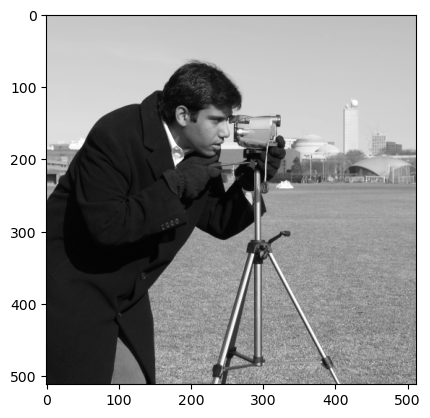

In [ ]:
import matplotlib.pyplot as plt
from skimage import data

# 이미지 로드 (예: 카메라 이미지)
image = data.camera()

# 이미지 보기
plt.imshow(image,cmap='gray')

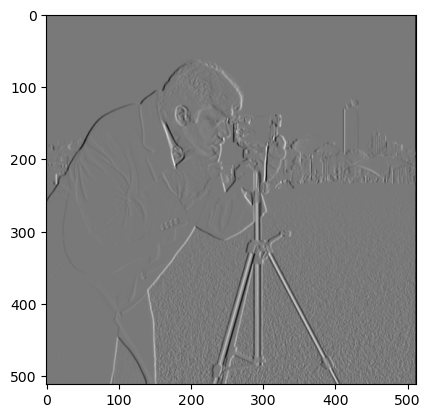

In [ ]:
import numpy as np
from scipy.signal import convolve2d

# 커널 생성
kernel = np.array([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]])

# 컨볼루션 연산 수행
result = convolve2d(image, kernel, mode='same')

# 결과 시각화
plt.imshow(result, cmap='gray')

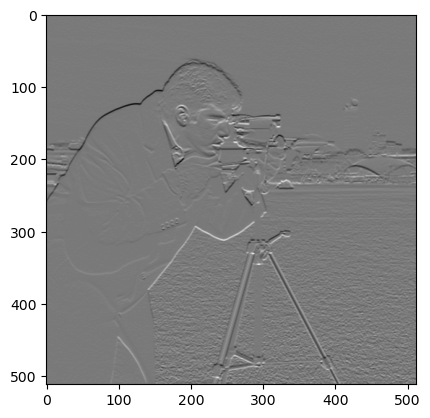

In [ ]:
# 세로방향 컨벌루션
# 커널 생성
kernel = np.array([[1, 2, 1],
                   [0, 0, 0],
                   [-1, -2, -1]])

# 컨볼루션 연산 수행
result = convolve2d(image, kernel, mode='same', boundary='symm')

# 결과 시각화
plt.imshow(result, cmap='gray')

원이미지 형태: (512, 512)
풀링후 이미지 형태: (512, 512)


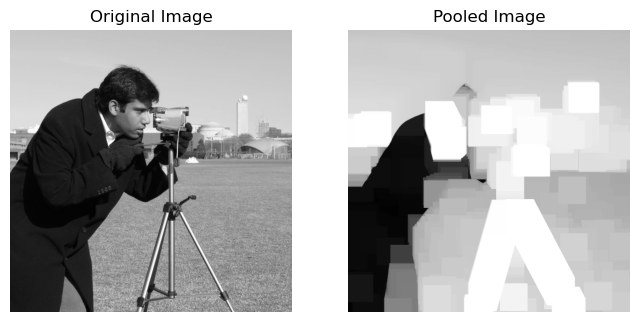

In [ ]:
# maxpool로 압축한 이미지
from scipy.ndimage import maximum_filter

image = data.camera()
print('원이미지 형태:',image.shape)

# maxpooling 적용
result = maximum_filter(image,size=(50,50))
print('풀링후 이미지 형태:',result.shape)

# 결과 시각화
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result, cmap='gray')
plt.title('Pooled Image'), plt.axis('off')

plt.show()

array([[2, 0, 3],
       [4, 0, 0],
       [4, 4, 0]])